# Pilot Experiments — Which Thesis Topic Does the RoboAI UR5e Data Support Best?

The exploration notebook (`robo_ai_ur5e_thesis_exploration.ipynb`) showed **what** is in the dataset. This notebook runs **small, fast pilot experiments** to measure **how much learnable signal** there is for each candidate thesis topic.

| Pilot | Candidate thesis topic | Question the pilot answers |
|---|---|---|
| 1 | Visuomotor / language-conditioned imitation learning | Can actions be predicted from the camera, and does the task instruction help? |
| 2 | Data-efficiency / fine-tuning study | Does performance still improve with more episodes? |
| 3 | Language grounding / task recognition | Can the task be recognized from video alone? |
| 4 | Progress estimation (success detection proxy) | Can the model tell how far a task has progressed from a single frame? |
| 5 | Sub-task / skill segmentation | Do episodes split cleanly into grasp–release phases? |
| 6 | Proprioceptive forecasting / anomaly detection | Is future robot motion predictable from past states? |

**Design choices (to keep pilots fast and comparable):**
- **GPU via PyTorch.** TensorFlow has no GPU support on native Windows, so TFDS only *reads* the data; all models run in PyTorch on CUDA.
- **Frozen image features.** Every camera frame is encoded once with an ImageNet-pretrained ResNet-18 (512-d) and cached. Pilots train small heads on these features, which gives a **lower bound** of what a full end-to-end model can reach.
- **Split by episode.** Test episodes are never seen during training (no leakage between neighbouring frames).

## 0 — Setup

In [1]:
import os, re, pickle, time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")   # TF is CPU-only on Windows anyway; keep it off the GPU
import tensorflow_datasets as tfds

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "no GPU")

DATASET_PATH = r"C:\Users\Nahid\Test\dataset"
CACHE_PATH = r"C:\Users\Nahid\Test\cache\resnet18_features.pkl"
SEED = 0
TEST_FRACTION = 0.2
pd.set_option("display.max_colwidth", 80)

PyTorch 2.5.1+cu121 | device: cuda | NVIDIA GeForce RTX 3090


C:\Users\Nahid\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Encode every frame once with ResNet-18 (GPU) and cache the result

This is the only slow step (JPEG decoding of ~57k frames at 480×640). It runs once; later runs load the cache in seconds. Delete the cache file to re-extract (e.g. after downloading more shards).

In [2]:
builder = tfds.builder_from_directory(DATASET_PATH)
info = builder.info
split_info = info.splits["train"]
available = 0
for i, n in enumerate(split_info.shard_lengths):
    shard = f"{info.name}-train.tfrecord-{i:05d}-of-{split_info.num_shards:05d}"
    if not os.path.exists(os.path.join(DATASET_PATH, shard)):
        break
    available += n
SPLIT = "train" if available == split_info.num_examples else f"train[:{available}]"
print(f"Episodes available: {available} of {split_info.num_examples} -> split {SPLIT!r}")

backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()
backbone = backbone.eval().to(DEVICE)
IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
IMNET_STD = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)

@torch.no_grad()
def embed(frames, batch=128):
    """(T, H, W, 3) uint8 -> (T, 512) float16 ResNet-18 features."""
    out = []
    for i in range(0, len(frames), batch):
        x = torch.from_numpy(frames[i:i + batch]).to(DEVICE).permute(0, 3, 1, 2).float() / 255.0
        x = F.interpolate(x, size=(224, 224), mode="bilinear", antialias=True, align_corners=False)
        x = (x - IMNET_MEAN) / IMNET_STD
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
            out.append(backbone(x).float().cpu().numpy())
    return np.concatenate(out).astype(np.float16)

def to_text(x):
    return x.decode("utf-8", errors="replace") if isinstance(x, bytes) else str(x)

cache_ok = False
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        episodes = pickle.load(f)
    cache_ok = len(episodes) == available
    print(f"Loaded cache with {len(episodes)} episodes" + ("" if cache_ok else " (stale, re-extracting)"))

if not cache_ok:
    os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
    episodes, t0 = [], time.time()
    for ep in tqdm(builder.as_dataset(split=SPLIT).prefetch(2), total=available, desc="encoding episodes"):
        steps = list(tfds.as_numpy(ep["steps"]))
        frames = np.stack([s["observation"]["image"] for s in steps])
        meta = ep["episode_metadata"]
        episodes.append({
            "feat": embed(frames),
            "state": np.stack([s["observation"]["robot_state"] for s in steps]).astype(np.float32),
            "action": np.stack([s["action"] for s in steps]).astype(np.float32),
            "instruction": to_text(steps[0]["language_instruction"]),
            "file_name": to_text(meta["file_name"].numpy()),
            "episode_index": int(meta["episode_index"].numpy()),
        })
    with open(CACHE_PATH, "wb") as f:
        pickle.dump(episodes, f)
    print(f"Encoded {len(episodes)} episodes in {(time.time() - t0) / 60:.1f} min -> {CACHE_PATH}")

print("Total frames:", sum(len(e["feat"]) for e in episodes))

Episodes available: 443 of 443 -> split 'train'


encoding episodes:   0%|          | 0/443 [00:00<?, ?it/s]

encoding episodes:   0%|          | 1/443 [00:02<21:32,  2.92s/it]

encoding episodes:   0%|          | 2/443 [00:03<09:41,  1.32s/it]

encoding episodes:   1%|          | 3/443 [00:03<05:48,  1.26it/s]

...

encoding episodes: 100%|█████████▉| 441/443 [01:02<00:00,  7.41it/s]

encoding episodes: 100%|█████████▉| 442/443 [01:02<00:00,  7.71it/s]

encoding episodes: 100%|██████████| 443/443 [01:03<00:00,  8.20it/s]

encoding episodes: 100%|██████████| 443/443 [01:03<00:00,  7.03it/s]

Encoded 443 episodes in 1.1 min -> C:\Users\Nahid\Test\cache\resnet18_features.pkl
Total frames: 57742


## 2 — Prepare labels: task names, rotation fix, train/test split

- **Task label.** Instructions are normalized (lower case, no articles/punctuation) so that paraphrases like *"stack cups"* and *"stack the cups"* become one task.
- **Rotation fix.** The exploration found rotation actions jumping to ±5.2 rad. Rotation deltas are wrapped into [−π, π] (this fixes pure angle wrap-around); steps that are still implausible afterwards (|Δrot| > 0.5 rad per step) are marked as glitches and excluded from training and evaluation. The printout shows how many steps each rule catches.

In [3]:
def normalize_instruction(s):
    s = re.sub(r"[^a-z ]", " ", s.lower())
    s = re.sub(r"\b(the|a|an)\b", " ", s)
    return re.sub(r"\s+", " ", s).strip()

for e in episodes:
    e["task"] = normalize_instruction(e["instruction"])
    a = e["action"].copy()
    raw_glitch = np.any(np.abs(a[:, 3:6]) > 0.5, axis=1)
    a[:, 3:6] = (a[:, 3:6] + np.pi) % (2 * np.pi) - np.pi
    e["action_fixed"] = a
    e["glitch_raw"] = raw_glitch
    e["glitch"] = np.any(np.abs(a[:, 3:6]) > 0.5, axis=1)

n_steps = sum(len(e["action"]) for e in episodes)
print(f"Rotation glitches before wrapping: {sum(e['glitch_raw'].sum() for e in episodes)} / {n_steps} steps")
print(f"Rotation glitches after wrapping:  {sum(e['glitch'].sum() for e in episodes)} / {n_steps} steps (excluded)")

task_counts = Counter(e["task"] for e in episodes)
print(f"\n{len(set(e['instruction'] for e in episodes))} raw instructions -> {len(task_counts)} normalized tasks")
display(pd.Series(task_counts, name="episodes").sort_values(ascending=False).to_frame())

rng = np.random.default_rng(SEED)
order = rng.permutation(len(episodes))
n_test = int(round(TEST_FRACTION * len(episodes)))
TEST_IDX, TRAIN_IDX = order[:n_test], order[n_test:]
print(f"Train episodes: {len(TRAIN_IDX)} | test episodes: {len(TEST_IDX)}")

Rotation glitches before wrapping: 359 / 57742 steps
Rotation glitches after wrapping:  358 / 57742 steps (excluded)

137 raw instructions -> 120 normalized tasks


,episodes
stack cups,207
stack blocks,94
stack cylinders,5
pick and place red block on blue block,4
stack yellow block on red block,3
...,...
stack blue cylinder on top of blue block,1
place blue block on top of yellow cube,1
pick and place blue cylinder on red block,1
pick and stack blue cylinder on blue block,1


Train episodes: 354 | test episodes: 89


### Shared helpers: a small MLP head trained on the GPU

In [4]:
def mlp(in_dim, out_dim, hidden=512, dropout=0.1):
    return nn.Sequential(
        nn.Linear(in_dim, hidden), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(hidden, hidden), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(hidden, out_dim),
    )

def train_head(Xtr, Ytr, Xte, loss_fn, out_dim, epochs=40, batch=1024, lr=1e-3, wd=1e-4, hidden=512, seed=SEED):
    """Trains an MLP on the GPU and returns its predictions for Xte."""
    torch.manual_seed(seed)
    model = mlp(Xtr.shape[1], out_dim, hidden).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    X = torch.as_tensor(Xtr, dtype=torch.float32, device=DEVICE)
    Y = torch.as_tensor(Ytr, device=DEVICE)
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(X), device=DEVICE)
        for i in range(0, len(X), batch):
            idx = perm[i:i + batch]
            loss = loss_fn(model(X[idx]), Y[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        return model(torch.as_tensor(Xte, dtype=torch.float32, device=DEVICE)).cpu().numpy()

def r2(pred, true):
    return 1 - ((pred - true) ** 2).sum(0) / (((true - true.mean(0)) ** 2).sum(0) + 1e-12)

def fit_norm(X):
    """Mean/std for standardization; (near-)constant columns such as one-hot ids are left unscaled."""
    sd = X.std(0)
    return X.mean(0), np.where(sd < 1e-8, 1.0, sd)

TASKS = sorted(task_counts)
TASK_ID = {t: i for i, t in enumerate(TASKS)}

## Pilot 1 — Visuomotor imitation learning: which inputs predict the action?

Four input variants predict the action at time *t*:

| Variant | Inputs |
|---|---|
| state | 15-d robot state |
| image | 512-d ResNet feature of the current frame |
| image + state | both |
| image + state + task | plus a one-hot task id (a simple stand-in for language conditioning) |

Metrics on held-out episodes: **R²** of the 6 continuous action dims (1 = perfect, 0 = no better than the mean) and **gripper accuracy**. If *image* ≫ *state*, the thesis needs vision; if *+ task* helps, language conditioning matters.

**Target.** Single-step actions are tiny, noisy deltas (the exploration notebook showed that even "repeat the previous action" is worse than predicting the mean). Modern policies (ACT, Diffusion Policy) therefore predict **action chunks**. The main target here is the **mean of the next `CHUNK` = 8 actions** for the continuous dims; the single-step R² is reported too for comparison.

In [5]:
CHUNK = 8

def chunk_mean(a, k):
    """Mean of a[t:t+k] for every t (shorter window at the end of the episode)."""
    c = np.cumsum(np.vstack([np.zeros((1, a.shape[1]), a.dtype), a]), axis=0)
    t = np.arange(len(a))
    end = np.minimum(t + k, len(a))
    return (c[end] - c[t]) / (end - t)[:, None]

for e in episodes:
    a = e["action_fixed"].copy()
    ok = ~e["glitch"]
    a[~ok, :6] = 0.0  # glitch steps must not leak into neighbouring chunk targets
    e["action_chunk"] = e["action_fixed"].copy()
    e["action_chunk"][:, :6] = chunk_mean(a[:, :6], CHUNK)

def build_bc(idx, use_img, use_state, use_task, stats=None, target="action_chunk"):
    X, Y = [], []
    for i in idx:
        e = episodes[i]
        keep = ~e["glitch"]
        parts = []
        if use_img:
            parts.append(e["feat"][keep].astype(np.float32))
        if use_state:
            parts.append(e["state"][keep])
        if use_task:
            onehot = np.zeros((keep.sum(), len(TASKS)), np.float32)
            onehot[:, TASK_ID[e["task"]]] = 1
            parts.append(onehot)
        X.append(np.concatenate(parts, 1))
        Y.append(e[target][keep])
    X, Y = np.concatenate(X), np.concatenate(Y)
    if stats is None:
        stats = (*fit_norm(X), *fit_norm(Y[:, :6]))
    x_mu, x_sd, y_mu, y_sd = stats
    Yn = Y.copy()
    Yn[:, :6] = (Y[:, :6] - y_mu) / y_sd
    Yn[:, 6] = (Y[:, 6] > 0.5).astype(np.float32)
    return (X - x_mu) / x_sd, Yn, stats

def bc_loss(pred, y):
    return F.mse_loss(pred[:, :6], y[:, :6]) + F.binary_cross_entropy_with_logits(pred[:, 6], y[:, 6])

def run_bc(use_img, use_state, use_task, train_idx=TRAIN_IDX, epochs=40, target="action_chunk"):
    Xtr, Ytr, stats = build_bc(train_idx, use_img, use_state, use_task, target=target)
    Xte, Yte, _ = build_bc(TEST_IDX, use_img, use_state, use_task, stats, target=target)
    pred = train_head(Xtr, Ytr, Xte, bc_loss, 7, epochs=epochs)
    dims = r2(pred[:, :6], Yte[:, :6])
    return {"R² continuous (mean)": float(dims.mean()),
            **{f"R² a[{i}]": float(d) for i, d in enumerate(dims)},
            "gripper accuracy": float(((pred[:, 6] > 0) == (Yte[:, 6] > 0.5)).mean())}

VARIANTS = {"state": (False, True, False), "image": (True, False, False),
            "image + state": (True, True, False), "image + state + task": (True, True, True)}
t0 = time.time()
bc_results = pd.DataFrame({name: run_bc(*flags) for name, flags in VARIANTS.items()}).T
bc_results.insert(1, "R² single-step (mean)",
                  [run_bc(*flags, target="action_fixed")["R² continuous (mean)"] for flags in VARIANTS.values()])
print(f"trained {2 * len(VARIANTS)} models in {time.time() - t0:.0f}s on {DEVICE}")
display(bc_results.round(3))

trained 8 models in 17s on cuda


,R² continuous (mean),R² single-step (mean),R² a[0],R² a[1],R² a[2],R² a[3],R² a[4],R² a[5],gripper accuracy
state,0.094,-0.121,0.060,0.129,0.176,0.085,0.105,0.009,1.000
image,-0.037,-0.044,-0.041,0.052,0.060,-0.081,-0.048,-0.165,0.822
image + state,0.030,-0.486,0.042,0.117,0.186,-0.047,0.032,-0.150,0.999
image + state + task,0.032,-0.456,0.040,0.142,0.209,-0.025,0.032,-0.207,1.000


## Pilot 2 — Data efficiency: does more data still help?

The best Pilot 1 variant is retrained on 10 / 25 / 50 / 100 % of the training episodes (same test set). A curve that is **still rising at 100 %** means the dataset size is the bottleneck, which strongly motivates a **pretrained foundation model / fine-tuning** thesis. A flat curve means the limit is the model or the inputs, not the data.

R²        gripper acc       
                    mean    std        mean    std
fraction episodes                                 
0.10     35       -0.208  0.053       0.891  0.010
0.25     88       -0.074  0.034       0.975  0.005
0.50     177      -0.002  0.036       0.998  0.000
1.00     354       0.032  0.006       1.000  0.000

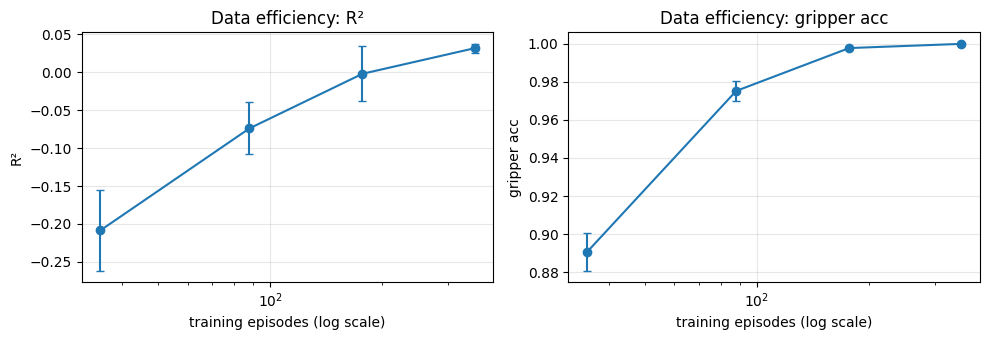

In [6]:
FRACTIONS = [0.1, 0.25, 0.5, 1.0]
curve = []
for frac in FRACTIONS:
    for rep in range(3):  # 3 random subsets per fraction for error bars
        sub = np.random.default_rng(SEED + rep).permutation(TRAIN_IDX)[:max(2, int(frac * len(TRAIN_IDX)))]
        res = run_bc(True, True, True, train_idx=sub)
        curve.append({"fraction": frac, "episodes": len(sub), "rep": rep,
                      "R²": res["R² continuous (mean)"], "gripper acc": res["gripper accuracy"]})
curve = pd.DataFrame(curve)
summary = curve.groupby(["fraction", "episodes"])[["R²", "gripper acc"]].agg(["mean", "std"]).round(3)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, col in zip(axes, ["R²", "gripper acc"]):
    g = curve.groupby("episodes")[col]
    ax.errorbar(g.mean().index, g.mean().values, yerr=g.std().values, marker="o", capsize=3)
    ax.set_xscale("log"); ax.set_xlabel("training episodes (log scale)"); ax.set_ylabel(col)
    ax.set_title(f"Data efficiency: {col}"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Pilot 3 — Task recognition from video (language grounding)

Each episode is summarized by the mean ResNet feature of its first, middle and last third (3 × 512). A classifier predicts the normalized task. Only tasks with at least 5 episodes are used, evaluated with **stratified 5-fold cross-validation** over episodes.

High accuracy (≫ majority baseline) means the tasks are visually distinct, so language grounding / instruction-following topics can be evaluated meaningfully. Low accuracy means the tasks look too similar, or the scenes vary more than the tasks do.

In [7]:
MIN_EPISODES = 5
keep_tasks = sorted(t for t, c in task_counts.items() if c >= MIN_EPISODES)
cls_idx = [i for i, e in enumerate(episodes) if e["task"] in keep_tasks]
y_cls = np.array([keep_tasks.index(episodes[i]["task"]) for i in cls_idx])

def episode_descriptor(e):
    thirds = np.array_split(e["feat"].astype(np.float32), 3)
    return np.concatenate([t.mean(0) for t in thirds])

X_cls = np.stack([episode_descriptor(episodes[i]) for i in cls_idx])

def stratified_folds(y, k=5, seed=SEED):
    rng = np.random.default_rng(seed)
    fold = np.zeros(len(y), int)
    for c in np.unique(y):
        members = rng.permutation(np.where(y == c)[0])
        fold[members] = np.arange(len(members)) % k
    return fold

print(f"{len(keep_tasks)} tasks with >= {MIN_EPISODES} episodes, {len(y_cls)} episodes")
if len(keep_tasks) < 2:
    task_acc = majority = float("nan")
    print("Fewer than 2 tasks with enough episodes: task recognition cannot be evaluated.")
else:
    folds = stratified_folds(y_cls)
    pred_cls = np.zeros(len(y_cls), int)
    for k in range(5):
        tr, te = folds != k, folds == k
        mu, sd = fit_norm(X_cls[tr])
        logits = train_head((X_cls[tr] - mu) / sd, y_cls[tr], (X_cls[te] - mu) / sd,
                            F.cross_entropy, len(keep_tasks), epochs=150, batch=64, hidden=256, wd=1e-2)
        pred_cls[te] = logits.argmax(1)

    task_acc = float((pred_cls == y_cls).mean())
    majority = float(np.bincount(y_cls).max() / len(y_cls))
    print(f"Task recognition accuracy: {task_acc:.1%}   (majority-class baseline: {majority:.1%})")

    per_task = pd.DataFrame({"task": [keep_tasks[c] for c in y_cls], "correct": pred_cls == y_cls})
    display(per_task.groupby("task")["correct"].agg(["count", "mean"]).rename(columns={"mean": "accuracy"})
            .sort_values("count", ascending=False).round(2))

3 tasks with >= 5 episodes, 306 episodes


Task recognition accuracy: 97.1%   (majority-class baseline: 67.6%)


,count,accuracy
task,,
stack cups,207,0.99
stack blocks,94,0.95
stack cylinders,5,0.80


## Pilot 4 — Progress estimation from a single frame

Predict normalized time *t / (T−1)* ∈ [0, 1] from one frame (+ state). Because the dataset has no success labels, **progress** is the closest self-supervised proxy for success/failure detection: a model that knows how far the task has progressed can flag episodes that stall or regress.

Baseline: always predicting 0.5 gives a mean absolute error (MAE) of about 0.25.

,MAE,baseline MAE (predict 0.5)
image,0.202,0.252
image + state,0.181,0.252


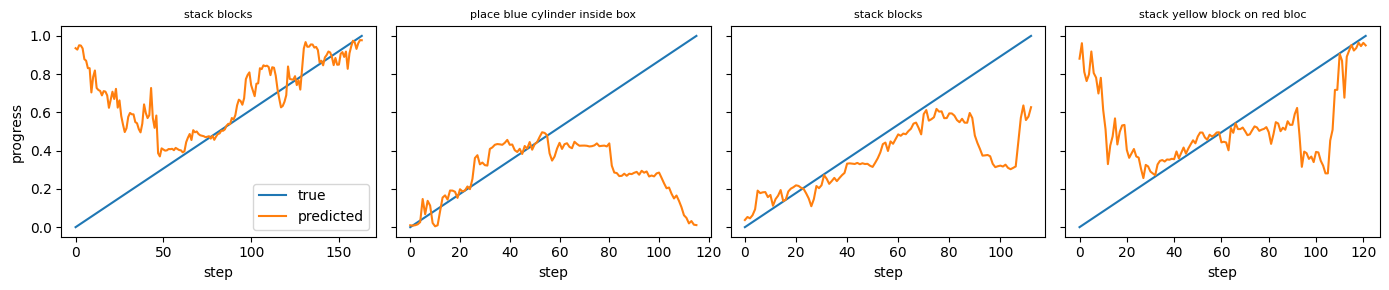

In [8]:
def build_progress(idx, use_state):
    X, Y = [], []
    for i in idx:
        e = episodes[i]
        T = len(e["feat"])
        parts = [e["feat"].astype(np.float32)] + ([e["state"]] if use_state else [])
        X.append(np.concatenate(parts, 1))
        Y.append(np.linspace(0, 1, T, dtype=np.float32))
    return np.concatenate(X), np.concatenate(Y)

progress_results = {}
for name, use_state in [("image", False), ("image + state", True)]:
    Xtr, Ytr = build_progress(TRAIN_IDX, use_state)
    Xte, Yte = build_progress(TEST_IDX, use_state)
    mu, sd = fit_norm(Xtr)
    pred = train_head((Xtr - mu) / sd, Ytr[:, None], (Xte - mu) / sd,
                      lambda p, y: F.mse_loss(torch.sigmoid(p), y), 1, epochs=30)
    pred = 1 / (1 + np.exp(-pred[:, 0]))
    progress_results[name] = {"MAE": float(np.abs(pred - Yte).mean()),
                              "baseline MAE (predict 0.5)": float(np.abs(0.5 - Yte).mean())}
    if use_state:
        last_pred, last_true = pred, Yte
display(pd.DataFrame(progress_results).T.round(3))

# plot predicted vs. true progress for 4 test episodes
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
start = 0
for ax, i in zip(axes, TEST_IDX[:4]):
    T = len(episodes[i]["feat"])
    ax.plot(last_true[start:start + T], label="true")
    ax.plot(last_pred[start:start + T], label="predicted")
    ax.set_title(episodes[i]["task"][:30], fontsize=8); ax.set_xlabel("step")
    start += T
axes[0].legend(); axes[0].set_ylabel("progress")
plt.tight_layout(); plt.show()

## Pilot 5 — Sub-task segmentation from gripper events

Every close→open cycle of the gripper is one grasp–move–release sub-task. If the number of grasps is **consistent within a task** (e.g. "stack 3 cups" always has 2–3 grasps), episodes split cleanly into primitives, giving free labels for a segmentation / hierarchical-policy thesis.

,episodes,mean_grasps,std_grasps,mode_share
task,,,,
stack cups,207,1.02,0.15,0.98
stack blocks,94,1.04,0.25,0.97
stack cylinders,5,1.00,0.00,1.00


Episodes whose grasp count equals their task's most common count: 97.4%


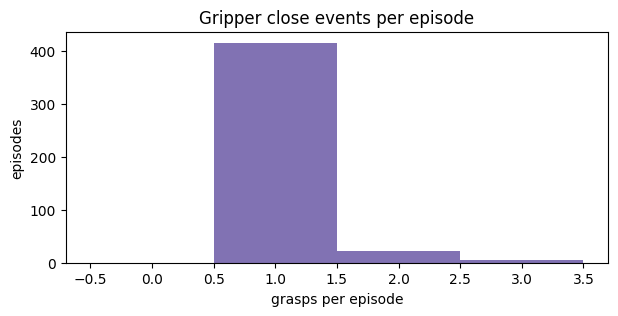

In [9]:
seg_rows = []
for e in episodes:
    g = (e["action"][:, 6] > 0.5).astype(int)
    closes = int(np.sum(np.diff(g) == 1) + (g[0] == 1))
    seg_rows.append({"task": e["task"], "grasps": closes, "length": len(g)})
seg = pd.DataFrame(seg_rows)

by_task = seg.groupby("task").agg(episodes=("grasps", "size"), mean_grasps=("grasps", "mean"),
                                  std_grasps=("grasps", "std"),
                                  mode_share=("grasps", lambda s: s.value_counts(normalize=True).iloc[0]))
by_task = by_task[by_task["episodes"] >= MIN_EPISODES].sort_values("episodes", ascending=False)
display(by_task.round(2))
seg_consistency = float((by_task["mode_share"] * by_task["episodes"]).sum() / by_task["episodes"].sum())
print(f"Episodes whose grasp count equals their task's most common count: {seg_consistency:.1%}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(seg["grasps"], bins=np.arange(seg["grasps"].max() + 2) - 0.5, color="#8172B3")
ax.set_xlabel("grasps per episode"); ax.set_ylabel("episodes"); ax.set_title("Gripper close events per episode")
plt.show()

## Pilot 6 — Forecasting robot motion from proprioception

Predict the change in robot state over the next *H* = 10 steps from the last *K* = 10 states. Two baselines:
- **no change**: the robot stays where it is
- **constant velocity**: the robot keeps its current velocity

If the learned model clearly beats constant velocity, motion is structured and predictable, which is a prerequisite for anomaly detection (large forecast errors = anomalies).

In [10]:
K, H = 10, 10

def build_forecast(idx):
    X, Y, CV = [], [], []
    for i in idx:
        s = episodes[i]["state"]
        for t in range(K - 1, len(s) - H):
            X.append(s[t - K + 1:t + 1].reshape(-1))
            Y.append(s[t + H] - s[t])
            CV.append((s[t] - s[t - 1]) * H)
    return np.array(X), np.array(Y), np.array(CV)

Xtr, Ytr, _ = build_forecast(TRAIN_IDX)
Xte, Yte, CVte = build_forecast(TEST_IDX)
x_mu, x_sd = fit_norm(Xtr)
y_mu, y_sd = fit_norm(Ytr)
pred = train_head((Xtr - x_mu) / x_sd, (Ytr - y_mu) / y_sd, (Xte - x_mu) / x_sd,
                  F.mse_loss, Ytr.shape[1], epochs=40) * y_sd + y_mu

nmse = lambda P: float(np.mean(((P - Yte) / y_sd) ** 2))
forecast_results = pd.Series({"no change": nmse(np.zeros_like(Yte)),
                              "constant velocity": nmse(CVte),
                              "MLP (last 10 states)": nmse(pred)}, name="normalized MSE (lower is better)")
display(forecast_results.round(3).to_frame())

,normalized MSE (lower is better)
no change,0.825
constant velocity,11.831
MLP (last 10 states),0.235


## Summary — pilot evidence per thesis topic

Each topic gets a **signal score** in [0, 1] measuring how far the pilot model gets from its trivial baseline towards a perfect score. This is evidence that there is something learnable to build a thesis on; it is **not** a prediction of final thesis results.

,topic,pilot result,signal
0,Sub-task segmentation,97% of episodes match their task's typical grasp count,0.97
1,Task recognition / language grounding,accuracy 97% vs majority 68%,0.91
2,Motion forecasting / anomaly detection,nMSE 0.235 vs const-velocity 11.831,0.72
3,Progress / success estimation,MAE 0.181 vs baseline 0.252,0.28
4,Fine-tuning / data-efficiency study,R² 10%->100% data: -0.21 -> 0.03; last doubling +0.034 (curve still rising),0.14
5,Visuomotor imitation learning,best R²=0.09; image adds -0.06 over state; gripper acc=1.00,0.09
6,Language-conditioned policy,task id adds +0.00 R²,0.02


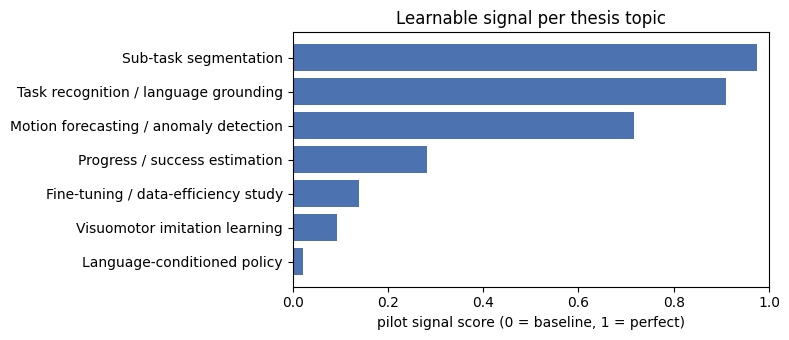

In [11]:
best_bc = bc_results["R² continuous (mean)"].max()
img_gain = bc_results.loc["image + state", "R² continuous (mean)"] - bc_results.loc["state", "R² continuous (mean)"]
task_gain = bc_results.loc["image + state + task", "R² continuous (mean)"] - bc_results.loc["image + state", "R² continuous (mean)"]
c = curve.groupby("fraction")["R²"].mean()
data_gain = c.loc[1.0] - c.loc[0.5]
prog = progress_results["image + state"]
fc = forecast_results

evidence = pd.DataFrame([
    {"topic": "Visuomotor imitation learning",
     "pilot result": f"best R²={best_bc:.2f}; image adds {img_gain:+.2f} over state; gripper acc={bc_results['gripper accuracy'].max():.2f}",
     "signal": max(0.0, best_bc)},
    {"topic": "Language-conditioned policy",
     "pilot result": f"task id adds {task_gain:+.2f} R²",
     "signal": float(np.clip(task_gain / max(best_bc, 1e-6), 0, 1))},
    {"topic": "Fine-tuning / data-efficiency study",
     "pilot result": f"R² 10%->100% data: {c.loc[0.1]:.2f} -> {c.loc[1.0]:.2f}; last doubling {data_gain:+.3f} "
                     f"(curve {'still rising' if data_gain > 0.01 else 'flat'})",
     # share of the final score gained in the last doubling of data: high = data-limited
     "signal": float(np.clip(data_gain / max(c.loc[1.0] - c.loc[0.1], 1e-6), 0, 1)) if c.loc[1.0] > 0 else 0.0},
    {"topic": "Task recognition / language grounding",
     "pilot result": f"accuracy {task_acc:.0%} vs majority {majority:.0%}",
     "signal": float(max(0.0, (task_acc - majority) / (1 - majority + 1e-6))) if task_acc == task_acc else 0.0},
    {"topic": "Progress / success estimation",
     "pilot result": f"MAE {prog['MAE']:.3f} vs baseline {prog['baseline MAE (predict 0.5)']:.3f}",
     "signal": float(max(0.0, 1 - prog["MAE"] / prog["baseline MAE (predict 0.5)"]))},
    {"topic": "Sub-task segmentation",
     "pilot result": f"{seg_consistency:.0%} of episodes match their task's typical grasp count",
     "signal": seg_consistency},
    {"topic": "Motion forecasting / anomaly detection",
     "pilot result": f"nMSE {fc['MLP (last 10 states)']:.3f} vs const-velocity {fc['constant velocity']:.3f}",
     "signal": float(max(0.0, 1 - fc["MLP (last 10 states)"] / min(fc["constant velocity"], fc["no change"])))},
]).sort_values("signal", ascending=False).reset_index(drop=True)
display(evidence.round(2))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(evidence["topic"][::-1], evidence["signal"][::-1], color="#4C72B0")
ax.set_xlim(0, 1); ax.set_xlabel("pilot signal score (0 = baseline, 1 = perfect)")
ax.set_title("Learnable signal per thesis topic"); plt.tight_layout(); plt.show()

## How to use these results

- **Signal is necessary, not sufficient.** A topic also needs a research gap, a baseline to beat, and an evaluation you can actually run (a real UR5e or simulation for policy topics).
- **Frozen ResNet features are a lower bound.** End-to-end fine-tuning, action chunking (ACT) or diffusion heads usually improve imitation results considerably; a weak pilot score for imitation learning is therefore less discouraging than a weak score for task recognition.
- **Recommended next step:** pick the 1–2 topics with the strongest evidence, and discuss them with your supervisor together with the data-quality notes (rotation glitches, paraphrased instructions, single camera).